In [12]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import glob
import os

def load_and_merge(folder_path, suffix=""):
    files = glob.glob(os.path.join(folder_path, "*.csv"))
    df_list = []
    
    for f in files:
        # Extract ticker name (e.g., 'aapl' from 'aapl_clean.csv')
        ticker = os.path.basename(f).split('_')[0].upper()
        df = pd.read_csv(f, index_col='Date', parse_dates=True)
        
        # We only need one price column to start (usually 'Adj Close')
        # Rename it to the ticker name to keep the columns unique
        df = df[['Close']].rename(columns={'Close': ticker + suffix})
        df_list.append(df)
    
    # Merge all on Date
    return pd.concat(df_list, axis=1)

# 1. Load both groups
df_etfs = load_and_merge('/Users/marysia/Desktop/applied/ml_project/Data_clean/ETF clean')
df_stocks = load_and_merge('/Users/marysia/Desktop/applied/ml_project/Data_clean/Stocks clean')

# 2. Combine into one Master DataFrame
master_df = pd.concat([df_etfs, df_stocks], axis=1).sort_index()

# 3. Clean: Forward fill missing days (holidays/early closes)
master_df.ffill(inplace=True)
master_df.dropna(inplace=True) # Drop the very first rows if they have NaNs

print(f"Master Dataset ready with {master_df.shape[1]} assets.")

Master Dataset ready with 43 assets.


In [10]:
master_df.head()

,QQQ,XLK,XLF,DIA,XLE,VT,SPY,XLV,IWM,VTI,...,PEP,BA,AAPL,GLD,JNJ,CRM,MCD,COP,MS,NKE
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-04,63.065,27.088,12.749,120.45,65.434,45.172,133.07,38.034,81.668,68.877,...,60.716,68.314,68.088,160.44,62.582,42.403,77.349,50.145,18.678,24.946
2013-01-07,63.083,27.051,12.721,119.95,64.931,44.940,132.72,38.156,81.357,68.675,...,60.707,66.943,67.689,159.43,62.451,42.245,78.260,49.595,18.316,24.986
2013-01-08,62.962,26.952,12.683,119.55,64.720,44.770,132.34,38.165,81.301,68.493,...,60.888,65.184,67.871,160.56,62.461,42.493,78.287,48.922,18.178,24.719
2013-01-09,63.197,26.997,12.669,120.12,64.612,44.966,132.67,38.583,81.695,68.703,...,61.195,67.497,66.808,160.49,62.741,42.958,78.177,48.823,18.148,24.742
2013-01-10,63.575,27.136,12.825,120.90,65.196,45.442,133.75,38.851,81.883,69.178,...,61.894,67.790,67.636,161.98,63.145,43.280,78.684,49.031,18.815,24.790


In [13]:
# Create Log Returns for all assets at once
returns_df = master_df.pct_change().apply(lambda x: np.log(1 + x))

# Calculate a 21-day Rolling Volatility for every asset
vol_df = returns_df.rolling(window=21).std()

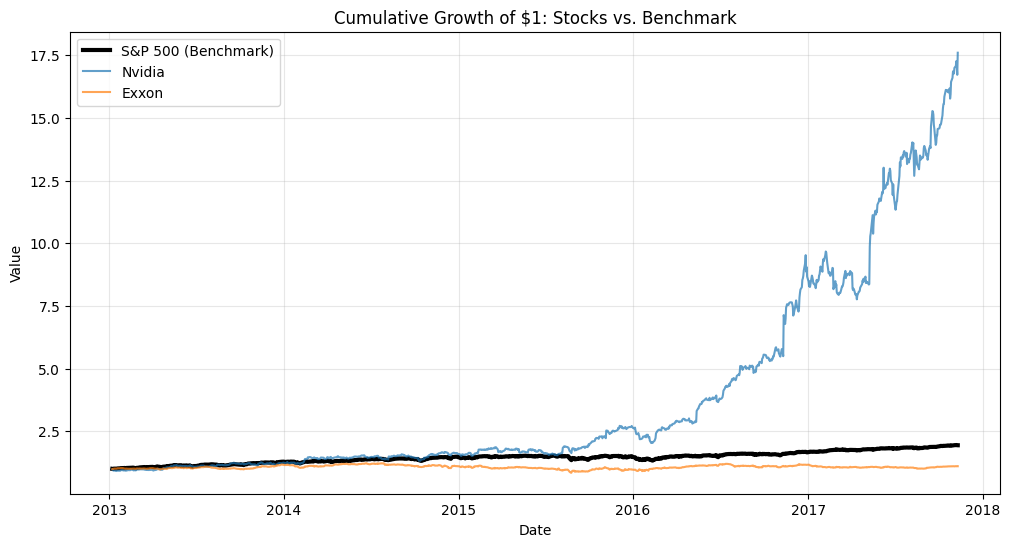

In [18]:
# Calculate Cumulative Returns: This shows growth over time
# We use .cumsum() on log returns then apply .exp()
cum_returns = returns_df.cumsum().apply(np.exp)

plt.figure(figsize=(12, 6))
plt.plot(cum_returns['SPY'], label='S&P 500 (Benchmark)', linewidth=3, color='black')
plt.plot(cum_returns['NVDA'], label='Nvidia', alpha=0.7)
plt.plot(cum_returns['XOM'], label='Exxon', alpha=0.7)

plt.title("Cumulative Growth of $1: Stocks vs. Benchmark")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
# 1. Define the Target: 1 if AAPL goes UP tomorrow, 0 if DOWN
# We shift(-1) to look at 'tomorrow'
y = (returns_df['AAPL'].shift(-1) > 0).astype(int)

# 2. Define Features: Use today's returns of all ETFs and a few Stocks
# We drop the last row because we don't know "tomorrow" for it yet
X = returns_df[['SPY', 'QQQ', 'XLK', 'XLF', 'AAPL', 'MSFT', 'NVDA']].iloc[:-1]
y = y.iloc[:-1]

# 3. Simple Time-Series Split (80% Train, 20% Test)
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

/Users/marysia/Desktop/applied/ml_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


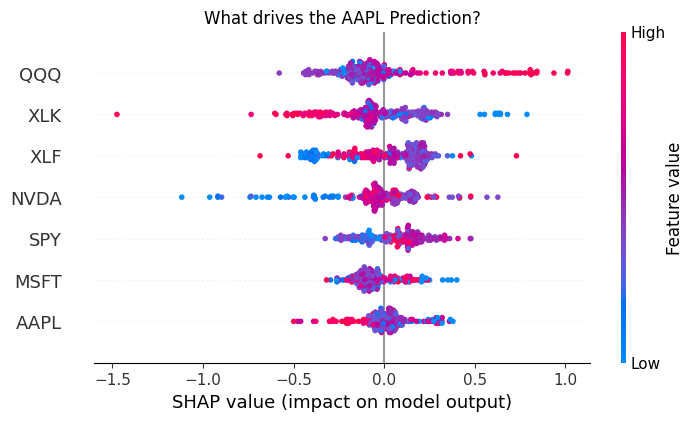

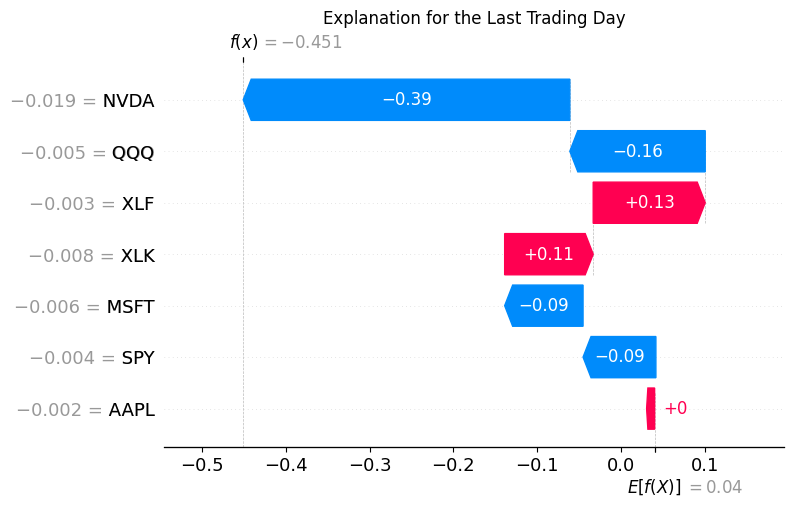

In [20]:
import xgboost as xgb
import shap

# 1. Train an XGBoost Classifier
model = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)

# 2. Initialize SHAP Explainer
explainer = shap.TreeExplainer(model)
# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# 3. Visual 1: Summary Plot (Global Importance)
# This shows which features matter most across the whole test set
plt.title("What drives the AAPL Prediction?")
shap.plots.beeswarm(shap_values)

# 4. Visual 2: Waterfall Plot (Local explanation)
# Why did the model predict 'UP' or 'DOWN' for the very last day in our data?
plt.title("Explanation for the Last Trading Day")
shap.plots.waterfall(shap_values[-1])